# Trabalho 2: Aprendizado de Máquina
**Disciplina:** Ciência de Dados

Neste notebook, realizamos a análise exploratória, o pré-processamento, tratamento de outliers, a modelagem e a avaliação do dataset **1985 Auto Imports** com o objetivo de prever o preço (`price`) dos veículos.

## 1. Importação das Bibliotecas

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento dos Dados
O dataset foi baixado do UCI Machine Learning Repository. Valores nulos estão representados pelo caractere `?`.

In [19]:
columns = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
    "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg",
    "price"
]

df = pd.read_csv("../data/imports-85.csv", names=columns, na_values="?")
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


## 3. Análise Exploratória de Dados (EDA)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

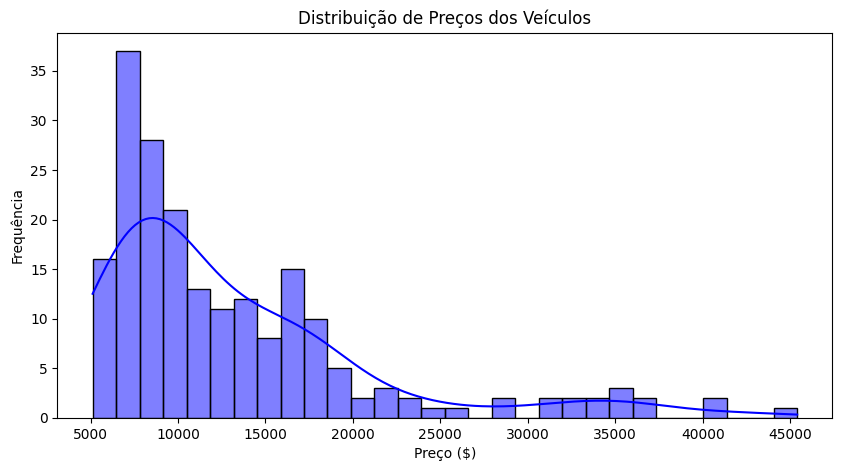

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'].dropna(), bins=30, kde=True, color='blue')
plt.title('Distribuição de Preços dos Veículos')
plt.xlabel('Preço ($)')
plt.ylabel('Frequência')
plt.show()

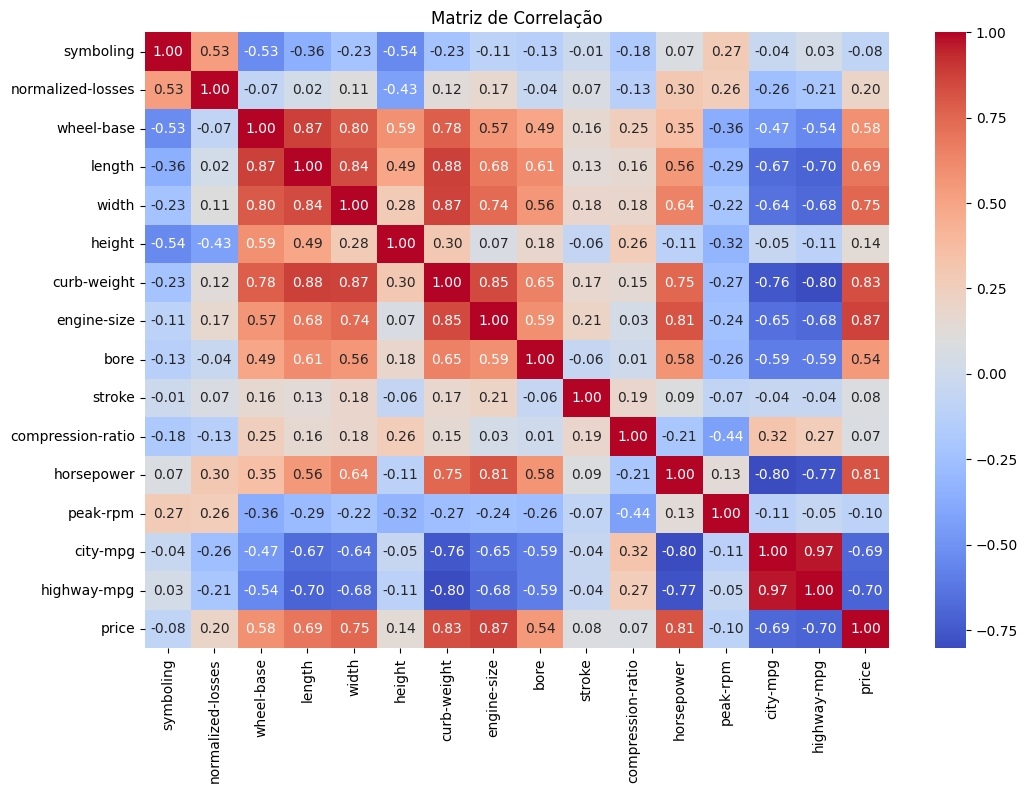

In [22]:
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.savefig("../data/matriz_correlacao.png")
plt.show()

## 4. Tratamento de Valores Nulos e Outliers (Limpeza de Dados)
Vamos remover linhas onde a variável alvo `price` é nula. Em seguida, vamos tratar outliers no `price` usando o método IQR para melhorar a robustez do modelo (atendendo ao critério CO12).

In [23]:
df = df.dropna(subset=['price'])
print(f"Registros após remoção de alvos nulos: {df.shape[0]}")

# Tratamento de Outliers com IQR no preço
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df_clean = df[df['price'] <= upper_bound]
print(f"Registros após remoção de outliers de preço: {df_clean.shape[0]}")
print(f"Outliers removidos: {df.shape[0] - df_clean.shape[0]}")

Registros após remoção de alvos nulos: 201
Registros após remoção de outliers de preço: 187
Outliers removidos: 14


## 5. Pré-processamento

In [24]:
X = df_clean.drop('price', axis=1)
y = df_clean['price']

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

## 6. Modelagem

In [26]:
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [27]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

## 7. Avaliação dos Resultados

In [28]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Modelo': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

results = []
results.append(evaluate_model(y_test, y_pred_lr, "Regressão Linear"))
results.append(evaluate_model(y_test, y_pred_rf, "Random Forest"))

results_df = pd.DataFrame(results)
results_df

,Modelo,RMSE,MAE,R²
0,Regressão Linear,1865.328101,1258.282778,0.788213
1,Random Forest,1539.497239,1069.373557,0.855740


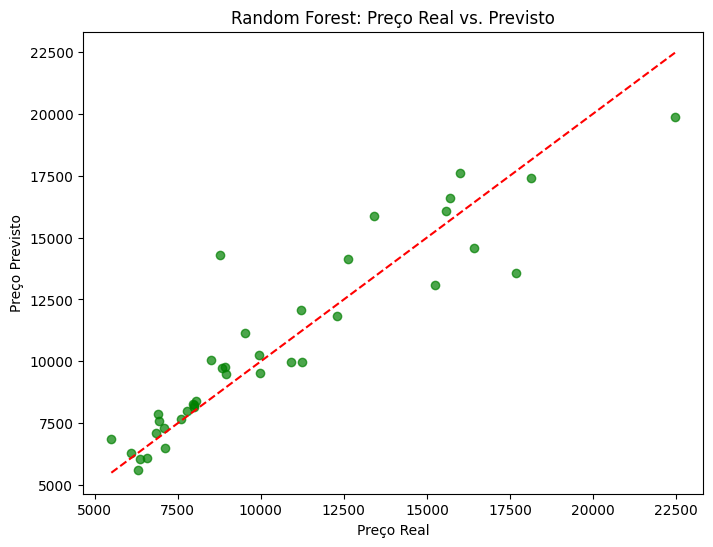

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')
plt.title('Random Forest: Preço Real vs. Previsto')
plt.savefig("../data/scatter_resultados.png")
plt.show()